#A single neuron with 4 inputs

In [1]:
inputs=[1,2,3,2.5]
weights=[0.2,0.8,-0.5,1.0]
bias=2


In [2]:
output=(inputs[0]*weights[0]+inputs[1]*weights[1]+inputs[2]*weights[2] + inputs[3]*weights[3]+bias)
print(output)


4.8


#Implementing a layer of neurons

In [3]:
inputs=[1,2,3,2.5]
weights1=[0.2,0.8,-0.5,1.0]
weights2 = [0.5, -0.91, 0.26, -0.5] 
weights3 = [-0.26, -0.27, 0.17, 0.87] 

bias1=2
bias2 = 3 
bias3 = 0.5 

In [4]:
outputs = [ 
        # Neuron 1: 
        inputs[0]*weights1[0] + 
        inputs[1]*weights1[1] + 
        inputs[2]*weights1[2] + 
        inputs[3]*weights1[3] + bias1, 
 
        # Neuron 2: 
        inputs[0]*weights2[0] + 
        inputs[1]*weights2[1] + 
        inputs[2]*weights2[2] + 
        inputs[3]*weights2[3] + bias2, 
 
        # Neuron 3: 
        inputs[0]*weights3[0] + 
        inputs[1]*weights3[1] + 
        inputs[2]*weights3[2] + 
        inputs[3]*weights3[3] + bias3] 
 
print(outputs) 

[4.8, 1.21, 2.385]


#Implementing NN using loop to scale and handle dynamically-sized inputs and layers

In [5]:
inputs = [1, 2, 3, 2.5] 
weights = [[0.2, 0.8, -0.5, 1], 
           [0.5, -0.91, 0.26, -0.5], 
           [-0.26, -0.27, 0.17, 0.87]] 
biases = [2, 3, 0.5] 

layer_output=[]
for input_weight,input_bias in zip(weights,biases):
    n_output=0
    for n_input,weight in zip(inputs,input_weight):
        n_output=n_input*weight + n_output
    n_output=n_output+input_bias
    layer_output.append(n_output)

#Single Neuron using dot product

In [6]:
import numpy as np
inputs = [1, 2, 3, 2.5] 
weights=[0.2,0.8,-0.5,1.0]
bias=2

In [7]:
outputs=np.dot(weights,inputs) + bias
print(outputs)

4.8


#Implementing layer of neurons using dot product

In [8]:
inputs = [1, 2, 3, 2.5] 
weights = [[0.2, 0.8, -0.5, 1], 
           [0.5, -0.91, 0.26, -0.5], 
           [-0.26, -0.27, 0.17, 0.87]] 
biases = [2, 3, 0.5]

layer_outputs=np.dot(weights,inputs)+biases
print(layer_outputs)

[4.8   1.21  2.385]


#A Layer of Neurons & Batch of Data w/ NumPy 

In [9]:
inputs = [[1, 2, 3, 2.5],
          [2,5,-1,2],
          [-1.5,2.7,3.3,-0.8] ]
weights = [[0.2, 0.8, -0.5, 1], 
           [0.5, -0.91, 0.26, -0.5], 
           [-0.26, -0.27, 0.17, 0.87]] 
biases = [2, 3, 0.5]
outputs=np.dot(inputs,np.array(weights).T)+biases
print(outputs)

[[ 4.8    1.21   2.385]
 [ 8.9   -1.81   0.2  ]
 [ 1.41   1.051  0.026]]


#Adding layers

In [10]:
inputs = [[1, 2, 3, 2.5],
          [2,5,-1,2],
          [-1.5,2.7,3.3,-0.8] ]
weights = [[0.2, 0.8, -0.5, 1], 
           [0.5, -0.91, 0.26, -0.5], 
           [-0.26, -0.27, 0.17, 0.87]] 
biases = [2, 3, 0.5]
weights2 = [[0.1, -0.14, 0.5], 
           [-0.5, 0.12, -0.33], 
           [-0.44, 0.73, -0.13]] 
biases2 = [-1, 2, -0.5]
layer1_outputs=np.dot(inputs,np.array(weights).T) + biases
layer2_outputs=np.dot(layer1_outputs,np.array(weights2).T) + biases2
print(layer2_outputs)

[[ 0.5031  -1.04185 -2.03875]
 [ 0.2434  -2.7332  -5.7633 ]
 [-0.99314  1.41254 -0.35655]]


 #Training Data

In [11]:
import numpy as np
import nnfs
nnfs.init()

In [12]:
from nnfs.datasets import spiral_data

#Spiral Data

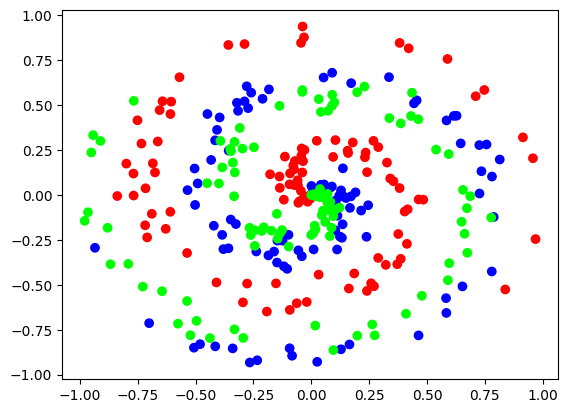

In [13]:
import matplotlib.pyplot as plt
X,y=spiral_data(samples=100, classes=3)
plt.scatter(X[:,0], X[:,1], c=y, cmap='brg')
plt.show()

#Dense Layer Class

In [14]:
class Layer_Dense:
    def __init__(self,n_inputs,n_neurons):
        self.weights=0.01*np.random.randn(n_inputs,n_neurons)
        self.biases= np.zeros((1,n_neurons))

    def forward(self, inputs):
        self.output=np.dot(inputs, self.weights) + self.biases
X,y=spiral_data(samples=100, classes=3)

dense1=Layer_Dense(2, 3)
dense1.forward(X)

print(dense1.output[:5])

[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-1.11171044e-04 -5.11007493e-05 -1.12099799e-04]
 [ 2.99257295e-06 -2.69126613e-04 -1.45165104e-04]
 [ 8.95101766e-05 -4.30442247e-04 -1.68079801e-04]
 [-3.49893759e-04 -3.07208364e-04 -4.33002861e-04]]


#Implement ReLU on Hidden Layers

In [15]:
class Activation_ReLU:
    def forward(self, inputs):
        self.output=np.maximum(0,inputs)
X,y=spiral_data(samples=100, classes=3)

dense1=Layer_Dense(2, 3)
#Creating ReLU activation
activ1=Activation_ReLU()
#Making a forward pass
dense1.forward(X)
#Passing the output through activation function 
activ1.forward(dense1.output)
print(activ1.output[:5])

        

[[0.0000000e+00 0.0000000e+00 0.0000000e+00]
 [1.3520580e-04 1.8173116e-05 0.0000000e+00]
 [2.3245417e-04 0.0000000e+00 0.0000000e+00]
 [3.8226307e-04 0.0000000e+00 0.0000000e+00]
 [5.7436468e-04 0.0000000e+00 0.0000000e+00]]


#Implementing Softmax Activation Function on Output

In [16]:
class Activation_Softmax:
    def forward(self,inputs):
        exp_values=np.exp(inputs-np.max(inputs,axis=1,keepdims=True))
        prob=exp_values/np.sum(exp_values,axis=1,keepdims=True)
        self.output=prob
dense1=Layer_Dense(2,3)
activ1=Activation_ReLU()
dense2=Layer_Dense(3,3)
activ2=Activation_Softmax()
dense1.forward(X)
activ1.forward(dense1.output)
dense2.forward(activ1.output)
activ2.forward(dense2.output)
print(activ2.output[:5])

[[0.33333334 0.33333334 0.33333334]
 [0.33333337 0.33333385 0.33333278]
 [0.3333339  0.3333335  0.3333326 ]
 [0.33333412 0.33333358 0.33333233]
 [0.33333385 0.3333346  0.33333156]]


Full Code:


In [17]:
import numpy as np
import nnfs
from nnfs.datasets import spiral_data
nnfs.init()

# Dense layer 
class Layer_Dense:
     # Layer initialization 
    def __init__(self,n_inputs,n_neurons):
        self.weights=0.01*np.random.randn(n_inputs,n_neurons)
        self.biases= np.zeros((1,n_neurons))
    # Forward pass 
    def forward(self, inputs):
        self.output=np.dot(inputs, self.weights) + self.biases
        
# ReLU activation 
class Activation_ReLU:
    def forward(self, inputs):
        self.output=np.maximum(0,inputs)

# Softmax activation 
class Activation_Softmax:
    def forward(self,inputs):
        exp_values=np.exp(inputs-np.max(inputs,axis=1,keepdims=True))
        prob=exp_values/np.sum(exp_values,axis=1,keepdims=True)
        self.output=prob

# Create dataset
X,y=spiral_data(samples=100, classes=3)

#Create Dense layer with 2 input features and 3 output values 
dense1=Layer_Dense(2,3)

# Create ReLU activation (to be used with Dense layer): 
activ1=Activation_ReLU()

#Second dense layer
dense2=Layer_Dense(3,3)

# Create Softmax activation (to be used with Dense layer): 
activ2=Activation_Softmax()

#Forward pass training data through this layer
dense1.forward(X)

#Make a forward pass through activation function
activ1.forward(dense1.output)

# Make a forward pass through second Dense layer 
dense2.forward(activ1.output)

# Make a forward pass through activation function 
activ2.forward(dense2.output)

print(activ2.output[:5])






[[0.33333334 0.33333334 0.33333334]
 [0.3333332  0.3333332  0.33333364]
 [0.3333329  0.33333293 0.3333342 ]
 [0.3333326  0.33333263 0.33333477]
 [0.33333233 0.3333324  0.33333528]]


#Implementing Loss Function

In [18]:
class Loss:
    def calculate(self,output,y):
        sample_losses=self.forward(output,y)
        data_loss=np.mean(sample_losses)

        return data_loss

In [19]:
class Loss_CategoricalCrossentropy(Loss):
    def forward(self, y_pred, y_true):
        samples=len(y_pred)

        y_pred_clipped=np.clip(y_pred, 1e-7, 1 - 1e-7)

        if len(y_true.shape)==1:
            correct_confidences = y_pred_clipped[range(samples),y_true]

        elif len(y_true.shape)==2:
            correct_confidences= np.sum(y_pred_clipped*y_true, axis=1)

        neg_log= -np.log(correct_confidences)
        return neg_log
            

In [20]:
loss_function= Loss_CategoricalCrossentropy()
loss=loss_function.calculate(activ2.output,y)
print('loss', loss)

loss 1.0986104


#Calculating Accuracy

In [23]:
pred=np.argmax(activ2.output,axis=1)
if len(y.shape)==2:
    y=np.argmax(y,axis=1)
accuracy=np.mean(pred==y)
print('acc:',accuracy)

acc: 0.34


#Introducing Optimaization


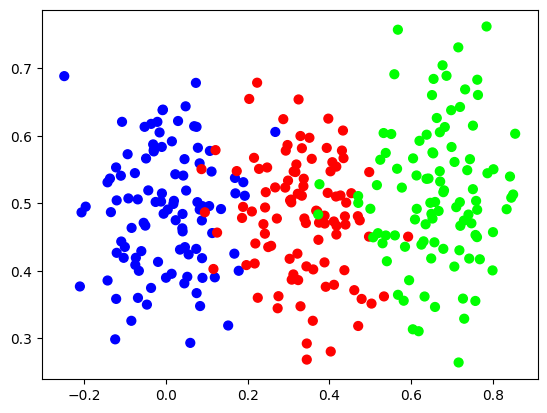

In [37]:
from nnfs.datasets import vertical_data

X,y=vertical_data(samples=100,classes=3)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap='brg') 
plt.show()

In [38]:
dense1=Layer_Dense(2,3)
activ1=Activation_ReLU()
dense2=Layer_Dense(3,3)
activ2=Activation_Softmax()
loss_function= Loss_CategoricalCrossentropy()

lowest_loss=999999
best_dense1_weights=dense1.weights.copy()
best_dense1_biases=dense1.biases.copy()
best_dense2_weights=dense2.weights.copy()
best_dense2_biases=dense2.biases.copy()

for i in range(10000):
    dense1.weights+=0.05*np.random.randn(2,3)
    dense1.biases+=0.05*np.random.randn(1,3)
    dense2.weights+=0.05*np.random.randn(3,3)
    dense2.biases+=0.05*np.random.randn(1,3)
    dense1.forward(X)
    activ1.forward(dense1.output)
    dense2.forward(activ1.output)
    activ2.forward(dense2.output)

    loss=loss_function.calculate(activ2.output,y)
    pred=np.argmax(activ2.output,axis=1)
    accuracy=np.mean(pred==y)

    if loss<lowest_loss:
        print(i,'loss:',loss,'acc:',accuracy)
        best_dense1_weights=dense1.weights.copy()
        best_dense1_biases=dense1.biases.copy()
        best_dense2_weights=dense2.weights.copy()
        best_dense2_biases=dense2.biases.copy()
        lowest_loss=loss
    else:
        dense1.weights=best_dense1_weights.copy()
        dense1.biases=best_dense1_biases.copy()
        dense2.weights=best_dense2_weights.copy()
        dense2.biases=best_dense2_biases.copy()
        
        




0 loss: 1.099795 acc: 0.3333333333333333
7 loss: 1.0989027 acc: 0.3333333333333333
8 loss: 1.0985888 acc: 0.3333333333333333
12 loss: 1.0969859 acc: 0.32
15 loss: 1.0929548 acc: 0.31333333333333335
17 loss: 1.0904992 acc: 0.33666666666666667
18 loss: 1.090306 acc: 0.44666666666666666
21 loss: 1.0894605 acc: 0.3333333333333333
27 loss: 1.0791603 acc: 0.6433333333333333
28 loss: 1.0757622 acc: 0.5566666666666666
36 loss: 1.071392 acc: 0.6233333333333333
37 loss: 1.0705884 acc: 0.5566666666666666
45 loss: 1.0680732 acc: 0.67
54 loss: 1.063031 acc: 0.48
55 loss: 1.0607307 acc: 0.6366666666666667
56 loss: 1.0473347 acc: 0.7266666666666667
63 loss: 1.0408775 acc: 0.48333333333333334
71 loss: 1.0391148 acc: 0.5366666666666666
74 loss: 1.0342768 acc: 0.5466666666666666
76 loss: 1.0314475 acc: 0.4033333333333333
79 loss: 1.0139611 acc: 0.6366666666666667
81 loss: 1.0097419 acc: 0.6366666666666667
82 loss: 1.0089964 acc: 0.6666666666666666
83 loss: 1.0011554 acc: 0.6633333333333333
84 loss: 1.00

In [40]:
X, y = spiral_data(samples=100, classes=3) 

dense1=Layer_Dense(2,3)
activ1=Activation_ReLU()
dense2=Layer_Dense(3,3)
activ2=Activation_Softmax()
loss_function= Loss_CategoricalCrossentropy()

lowest_loss=999999
best_dense1_weights=dense1.weights.copy()
best_dense1_biases=dense1.biases.copy()
best_dense2_weights=dense2.weights.copy()
best_dense2_biases=dense2.biases.copy()

for i in range(10000):
    dense1.weights+=0.05*np.random.randn(2,3)
    dense1.biases+=0.05*np.random.randn(1,3)
    dense2.weights+=0.05*np.random.randn(3,3)
    dense2.biases+=0.05*np.random.randn(1,3)
    dense1.forward(X)
    activ1.forward(dense1.output)
    dense2.forward(activ1.output)
    activ2.forward(dense2.output)

    loss=loss_function.calculate(activ2.output,y)
    pred=np.argmax(activ2.output,axis=1)
    accuracy=np.mean(pred==y)

    if loss<lowest_loss:
        print(i,'loss:',loss,'acc:',accuracy)
        best_dense1_weights=dense1.weights.copy()
        best_dense1_biases=dense1.biases.copy()
        best_dense2_weights=dense2.weights.copy()
        best_dense2_biases=dense2.biases.copy()
        lowest_loss=loss
    else:
        dense1.weights=best_dense1_weights.copy()
        dense1.biases=best_dense1_biases.copy()
        dense2.weights=best_dense2_weights.copy()
        dense2.biases=best_dense2_biases.copy()
        
        




0 loss: 1.0986103 acc: 0.3333333333333333
6 loss: 1.0986054 acc: 0.3466666666666667
22 loss: 1.0984812 acc: 0.32
24 loss: 1.098415 acc: 0.3333333333333333
29 loss: 1.0983585 acc: 0.3333333333333333
33 loss: 1.098252 acc: 0.3333333333333333
37 loss: 1.0981915 acc: 0.3333333333333333
38 loss: 1.0979698 acc: 0.38666666666666666
56 loss: 1.0975518 acc: 0.3233333333333333
58 loss: 1.0970944 acc: 0.36666666666666664
61 loss: 1.0970081 acc: 0.3333333333333333
75 loss: 1.0963064 acc: 0.37333333333333335
76 loss: 1.0959567 acc: 0.35
82 loss: 1.0956092 acc: 0.32666666666666666
87 loss: 1.0954282 acc: 0.38666666666666666
90 loss: 1.0953053 acc: 0.3433333333333333
95 loss: 1.0952538 acc: 0.3433333333333333
98 loss: 1.0942893 acc: 0.37
99 loss: 1.0933044 acc: 0.34
109 loss: 1.092537 acc: 0.35333333333333333
113 loss: 1.0907489 acc: 0.3933333333333333
119 loss: 1.0906502 acc: 0.38
120 loss: 1.0870805 acc: 0.3933333333333333
123 loss: 1.0869982 acc: 0.38
131 loss: 1.0863782 acc: 0.4033333333333333
13